In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 1. Create a synthetic e-commerce dataset
np.random.seed(42)
n_rows = 5000

data = {
    'Order_ID': np.arange(1000, 1000 + n_rows),
    'Order_Date': [datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_rows)],
    'Product': np.random.choice(['iPhone', 'Google Phone', 'Wired Headphones', 'Vareebadd Phone', 'USB-C Charging Cable', 'Lightning Charging Cable', 'Macbook Pro Laptop'], n_rows),
    'Quantity_Ordered': np.random.randint(1, 5, n_rows),
    'Price_Each': np.random.uniform(10, 1700, n_rows),
    'Purchase_Address': np.random.choice(['Melbourne, VIC', 'Sydney, NSW', 'Brisbane, QLD', 'Adelaide, SA', 'Perth, WA'], n_rows)
}

df_sales = pd.DataFrame(data)

# 2. Data Cleaning: Ensure correct data types
df_sales['Order_Date'] = pd.to_datetime(df_sales['Order_Date'])
df_sales['Sales'] = df_sales['Quantity_Ordered'] * df_sales['Price_Each']

print("Transactional Data Loaded and Cleaned.")
print(df_sales.head())

Transactional Data Loaded and Cleaned.
   Order_ID Order_Date                   Product  Quantity_Ordered  \
0      1000 2023-04-13  Lightning Charging Cable                 3   
1      1001 2023-12-15           Vareebadd Phone                 3   
2      1002 2023-09-28              Google Phone                 2   
3      1003 2023-04-17        Macbook Pro Laptop                 4   
4      1004 2023-03-13           Vareebadd Phone                 3   

    Price_Each Purchase_Address        Sales  
0  1379.631624        Perth, WA  4138.894872  
1  1175.595594      Sydney, NSW  3526.786782  
2  1235.031743     Adelaide, SA  2470.063485  
3  1189.817602   Melbourne, VIC  4759.270407  
4   535.544406   Melbourne, VIC  1606.633218  


In [2]:
# Extracting Month and City for granular analysis
df_sales['Month'] = df_sales['Order_Date'].dt.month
df_sales['City'] = df_sales['Purchase_Address'].apply(lambda x: x.split(',')[0])

# FIX: Add 'numeric_only=True' so Pandas ignores the Date and Text columns
monthly_sales = df_sales.groupby('Month').sum(numeric_only=True)['Sales']
city_sales = df_sales.groupby('City').sum(numeric_only=True)['Sales']

print("Feature Engineering Complete: Monthly and City-level metrics aggregated.")
print(monthly_sales.head())

Feature Engineering Complete: Monthly and City-level metrics aggregated.
Month
1    832572.151980
2    829053.169230
3    862728.903775
4    948029.560565
5    950672.024451
Name: Sales, dtype: float64


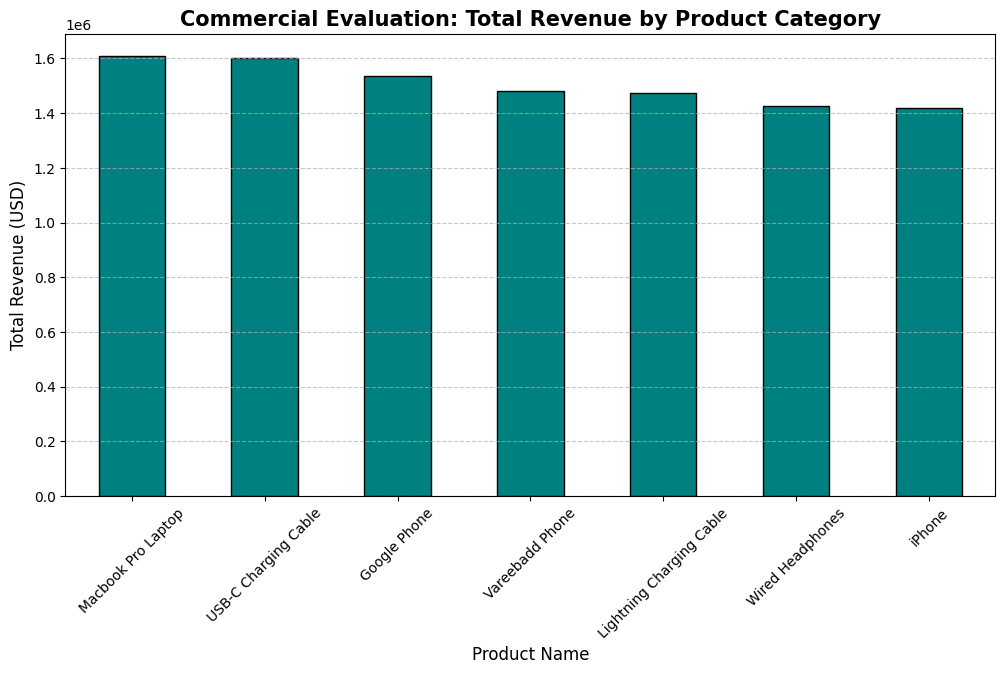

Top 3 Revenue Generating Products:
Product
Macbook Pro Laptop      1.608511e+06
USB-C Charging Cable    1.599775e+06
Google Phone            1.536029e+06
Name: Sales, dtype: float64


In [3]:
# 1. Calculate Total Revenue per Product
# We sort by 'Sales' to see our top performers at a glance
product_performance = df_sales.groupby('Product').sum(numeric_only=True)['Sales'].sort_values(ascending=False)

# 2. Visualizing Product Performance for Stakeholders
plt.figure(figsize=(12, 6))
product_performance.plot(kind='bar', color='teal', edgecolor='black')

# Adding professional labels
plt.title('Commercial Evaluation: Total Revenue by Product Category', fontsize=15, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 3. Print the 'Top 3' products for your interview notes
print("Top 3 Revenue Generating Products:")
print(product_performance.head(3))

/tmp/ipykernel_8613/236291110.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=city_sales.index, y=city_sales.values, palette='magma')


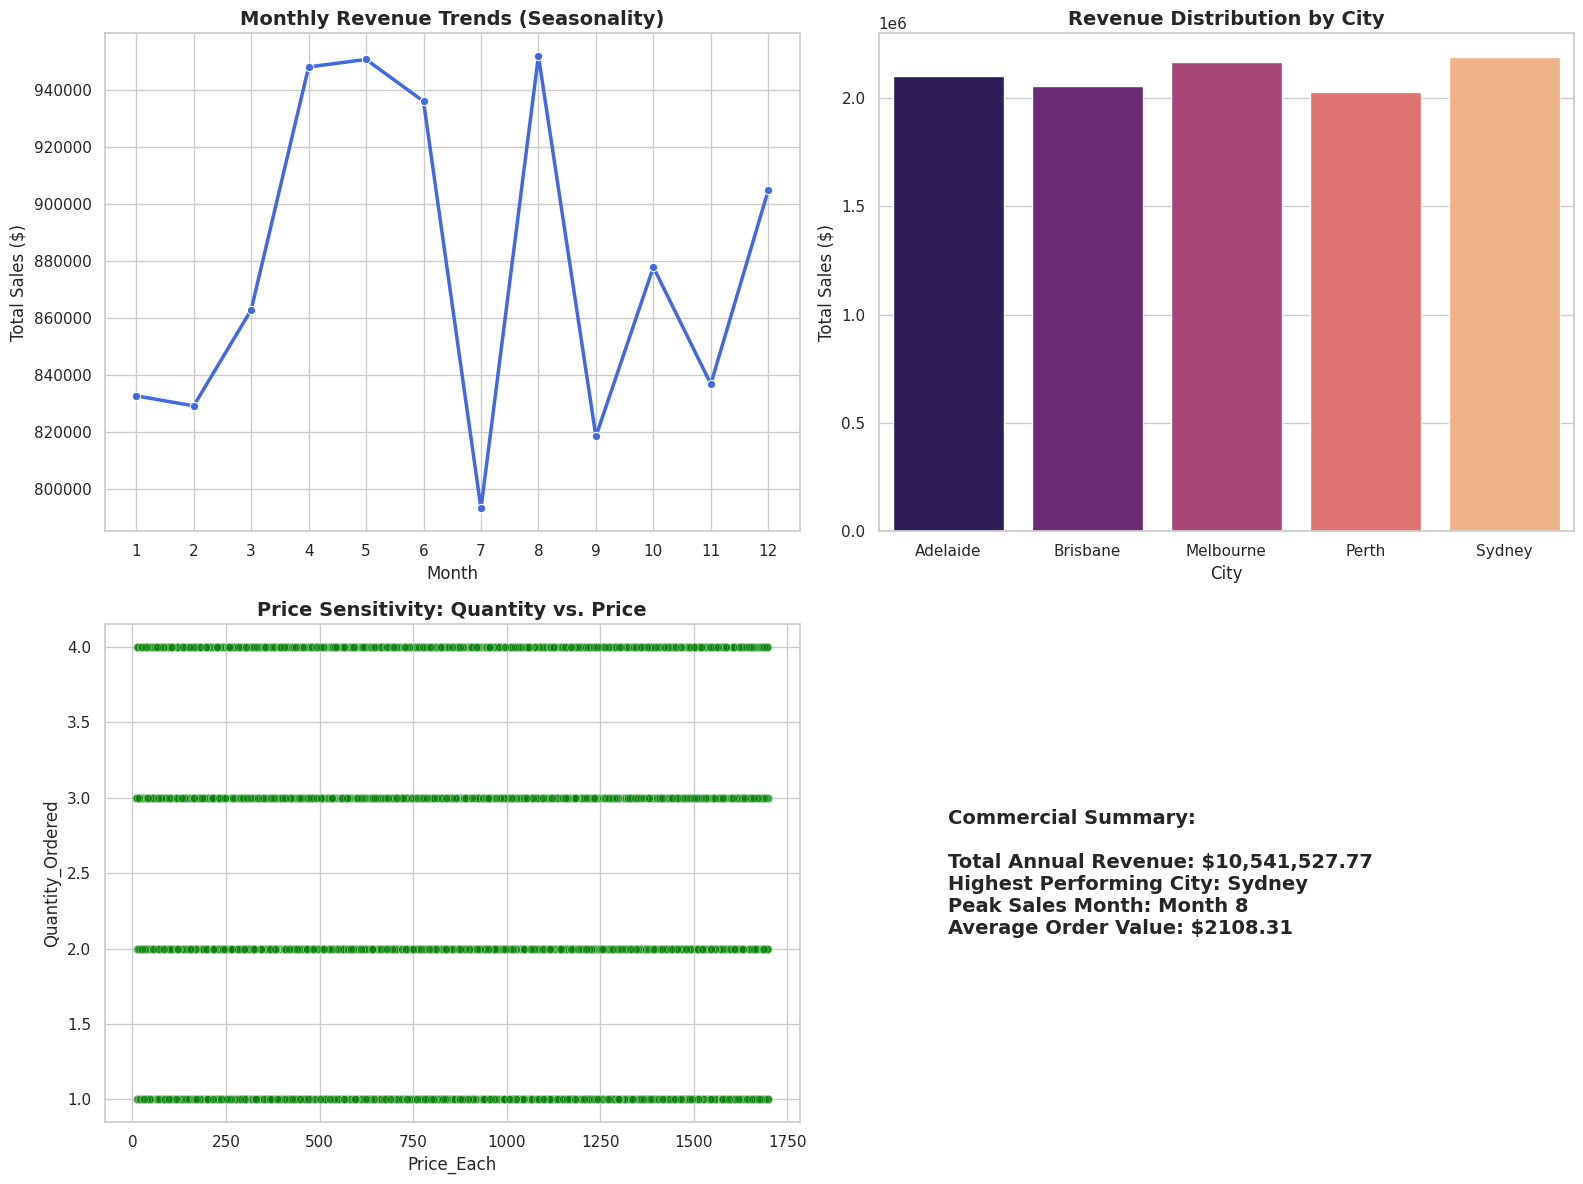

In [4]:
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Seasonal Revenue Trend (Line Chart)
sns.lineplot(ax=axes[0, 0], x=monthly_sales.index, y=monthly_sales.values, marker='o', color='royalblue', linewidth=2.5)
axes[0, 0].set_title('Monthly Revenue Trends (Seasonality)', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_ylabel('Total Sales ($)')

# 2. City-Level Insights (Bar Chart)
sns.barplot(ax=axes[0, 1], x=city_sales.index, y=city_sales.values, palette='magma')
axes[0, 1].set_title('Revenue Distribution by City', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Sales ($)')

# 3. Price vs. Quantity Ordered (Scatter Plot)
# Helps identify if cheaper items sell in significantly higher volumes
sns.scatterplot(ax=axes[1, 0], data=df_sales, x='Price_Each', y='Quantity_Ordered', alpha=0.4, color='green')
axes[1, 0].set_title('Price Sensitivity: Quantity vs. Price', fontsize=14, fontweight='bold')

# 4. Summary Table (Textual Insight)
axes[1, 1].axis('off')
stats_text = (
    f"Commercial Summary:\n\n"
    f"Total Annual Revenue: ${df_sales['Sales'].sum():,.2f}\n"
    f"Highest Performing City: {city_sales.idxmax()}\n"
    f"Peak Sales Month: Month {monthly_sales.idxmax()}\n"
    f"Average Order Value: ${df_sales['Sales'].mean():.2f}"
)
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=14, fontweight='bold', verticalalignment='center')

plt.tight_layout()
plt.show()